In [74]:
import sys
print(sys.executable)

c:\Users\Ravichandran\OneDrive\Desktop\Ml Alogiritms dally progress\.venv\Scripts\python.exe


In [75]:
import os
import sys
import pandas as pd
crime = pd.read_json("data/raw/bail_judgments/bail_judgments.json", lines=True)
crime = crime.copy()

In [76]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [77]:
crime.head()

,case_id,case_title,court,date,judge,ipc_sections,bail_type,bail_cancellation_case,landmark_case,accused_name,...,facts,legal_issues,judgment_reason,summary,bias_flag,parity_argument_used,legal_principles_discussed,region,source_filename,special_laws
0,1,Jibangshu Paul vs National Investigation Agency,Gauhati High Court,2011-07-27,"Justice I. A. Ansari, Justice A. K. Goswami","['120B', '121', '121A']",Regular,True,True,Jibangshu Paul,...,Jibangshu Paul was apprehended carrying Rs. 32...,"['Whether fresh bail is needed when new, more ...",The court held that newly added serious UA(P) ...,Bail earlier granted to Jibangshu Paul under I...,False,False,['Addition of new penal sections requires fres...,Assam,case0001.PDF,None
1,2,State By The Superintendent Of Police vs Mehbo...,Madras High Court,1997-09-30,Justice E. Padmanabhan,"['376', '354', '343', '109', '220', '348', '33...",Regular,True,False,Mehboob Batcha and others (A1 to A11),...,The case involves custodial rape of a woman by...,['Whether suspension of sentence requires deta...,The court held that due to the grave nature of...,Madras High Court cancelled the bail granted t...,False,False,[],Tamil Nadu,case0002.PDF,None
2,3,Hyderali vs State Of Kerala,Kerala High Court,2008-08-05,Justice K. Hema,"['465', '468', '471', '474', '420', '511', '34']",Anticipatory,False,True,Hyderali,...,"Hyderali, a government contractor, was accused...",['Whether anticipatory bail can be granted whe...,The court ruled that despite other co-accused ...,Kerala High Court rejected anticipatory bail f...,False,True,['Custodial interrogation is legitimate and ma...,Kerala,case0003.PDF,None
3,4,Rashbehari Karmakar vs Indrajit Mukherjee And ...,Calcutta High Court,2002-07-12,"Justice P.K. Biswas, Justice S. Barman Roy","['326', '307', '120B', '201']",Regular,True,False,Indrajit Mukherjee,...,"The petitioner, a government employee, alleged...",['Whether bail should be cancelled under Secti...,The court found no cogent or overwhelming reas...,Calcutta High Court refused to cancel bail of ...,False,False,['Difference between grant and cancellation of...,West Bengal,case0004.PDF,None
4,5,Smt. Shankri Devi Age 62 Years vs Union Territ...,High Court of Jammu & Kashmir and Ladakh at Jammu,2023-06-12,Justice Mohan Lal,"['302', '34']",Regular,False,False,Smt. Shankri Devi,...,Shankri Devi and co-accused were charged with ...,['Whether the court’s earlier bail rejection o...,The court held that its earlier rejection of b...,Jammu & Kashmir High Court rejected the review...,False,False,['Bail once rejected cannot be reviewed except...,Jammu & Kashmir,case0005.PDF,None


In [78]:
crime.columns

Index(['case_id', 'case_title', 'court', 'date', 'judge', 'ipc_sections',
       'bail_type', 'bail_cancellation_case', 'landmark_case', 'accused_name',
       'accused_gender', 'prior_cases', 'bail_outcome',
       'bail_outcome_label_detailed', 'crime_type', 'facts', 'legal_issues',
       'judgment_reason', 'summary', 'bias_flag', 'parity_argument_used',
       'legal_principles_discussed', 'region', 'source_filename',
       'special_laws'],
      dtype='object')

In [79]:
crime.describe()

,case_id,date
count,1200.000000,1200
mean,600.500000,2019-10-25 08:42:00.000000256
min,1.000000,1975-08-18 00:00:00
25%,300.750000,2018-10-10 06:00:00
50%,600.500000,2022-04-02 12:00:00
75%,900.250000,2024-02-20 06:00:00
max,1200.000000,2025-06-02 00:00:00
std,346.554469,NaN


In [80]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   case_id                      1200 non-null   int64         
 1   case_title                   1200 non-null   object        
 2   court                        1200 non-null   object        
 3   date                         1200 non-null   datetime64[ns]
 4   judge                        1200 non-null   object        
 5   ipc_sections                 1200 non-null   object        
 6   bail_type                    1200 non-null   object        
 7   bail_cancellation_case       1200 non-null   bool          
 8   landmark_case                1200 non-null   bool          
 9   accused_name                 1200 non-null   object        
 10  accused_gender               1200 non-null   object        
 11  prior_cases                  1200 non-null 

In [81]:
crime.isnull().sum()

case_id                           0
case_title                        0
court                             0
date                              0
judge                             0
ipc_sections                      0
bail_type                         0
bail_cancellation_case            0
landmark_case                     0
accused_name                      0
accused_gender                    0
prior_cases                       0
bail_outcome                      0
bail_outcome_label_detailed       0
crime_type                        0
facts                             0
legal_issues                      0
judgment_reason                   0
summary                           0
bias_flag                         0
parity_argument_used              0
legal_principles_discussed        3
region                            0
source_filename                   0
special_laws                   1163
dtype: int64

In [82]:
crime.iloc[0].keys

<bound method Series.keys of case_id                                                                        1
case_title                       Jibangshu Paul vs National Investigation Agency
court                                                         Gauhati High Court
date                                                         2011-07-27 00:00:00
judge                                Justice I. A. Ansari, Justice A. K. Goswami
ipc_sections                                             ['120B', '121', '121A']
bail_type                                                                Regular
bail_cancellation_case                                                      True
landmark_case                                                               True
accused_name                                                      Jibangshu Paul
accused_gender                                                              Male
prior_cases                                                              Unknown

In [83]:
crime.iloc[0]['facts']

'Jibangshu Paul was apprehended carrying Rs. 32,11,000 in cash, suspected to be intended for the DHD(J) militant group. He was earlier granted bail for IPC sections. Later, serious sections under the Unlawful Activities (Prevention) Act were added, and NIA sought his re-arrest. The Special Court directed custody, rejecting his prayer to continue on earlier bail.'

In [84]:
crime.iloc[0]['crime_type']

'Narcotics'

In [85]:
crime.iloc[0]['ipc_sections']

"['120B', '121', '121A']"

In [86]:
crime['crime_type'].value_counts()

crime_type
Narcotics            134
Theft or Robbery     128
Dowry Harassment     123
Sexual Offense       121
Fraud or Cheating    121
Cyber Crime          116
Extortion            106
Kidnapping            95
Murder                89
Others                75
Domestic Violence     72
Attempt to Murder     20
Name: count, dtype: int64

In [87]:
crime['crime_type'].unique()

array(['Narcotics', 'Sexual Offense', 'Fraud or Cheating', 'Others',
       'Murder', 'Dowry Harassment', 'Theft or Robbery', 'Kidnapping',
       'Attempt to Murder', 'Domestic Violence', 'Cyber Crime',
       'Extortion'], dtype=object)

In [88]:
crime['facts'].str.len().describe()

count    1200.000000
mean      375.625000
std        66.637864
min       196.000000
25%       332.000000
50%       375.000000
75%       418.000000
max       611.000000
Name: facts, dtype: float64

In [89]:
crime['crime_type'][:10]

0            Narcotics
1       Sexual Offense
2    Fraud or Cheating
3               Others
4               Murder
5               Murder
6               Murder
7               Murder
8               Murder
9            Narcotics
Name: crime_type, dtype: object

## droping unwanted columns 

In [90]:
crime.drop(['case_id','case_title','court','date','judge','bail_type','bail_cancellation_case','landmark_case','accused_name','accused_gender',
           'prior_cases','bail_outcome','bail_outcome_label_detailed','bias_flag','parity_argument_used',
           'legal_principles_discussed','source_filename'] , axis=1 , inplace=True)

In [91]:
crime.columns

Index(['ipc_sections', 'crime_type', 'facts', 'legal_issues',
       'judgment_reason', 'summary', 'region', 'special_laws'],
      dtype='object')

In [92]:
crime.head()

,ipc_sections,crime_type,facts,legal_issues,judgment_reason,summary,region,special_laws
0,"['120B', '121', '121A']",Narcotics,Jibangshu Paul was apprehended carrying Rs. 32...,"['Whether fresh bail is needed when new, more ...",The court held that newly added serious UA(P) ...,Bail earlier granted to Jibangshu Paul under I...,Assam,None
1,"['376', '354', '343', '109', '220', '348', '33...",Sexual Offense,The case involves custodial rape of a woman by...,['Whether suspension of sentence requires deta...,The court held that due to the grave nature of...,Madras High Court cancelled the bail granted t...,Tamil Nadu,None
2,"['465', '468', '471', '474', '420', '511', '34']",Fraud or Cheating,"Hyderali, a government contractor, was accused...",['Whether anticipatory bail can be granted whe...,The court ruled that despite other co-accused ...,Kerala High Court rejected anticipatory bail f...,Kerala,None
3,"['326', '307', '120B', '201']",Others,"The petitioner, a government employee, alleged...",['Whether bail should be cancelled under Secti...,The court found no cogent or overwhelming reas...,Calcutta High Court refused to cancel bail of ...,West Bengal,None
4,"['302', '34']",Murder,Shankri Devi and co-accused were charged with ...,['Whether the court’s earlier bail rejection o...,The court held that its earlier rejection of b...,Jammu & Kashmir High Court rejected the review...,Jammu & Kashmir,None


In [93]:
crime.isnull().sum()

ipc_sections          0
crime_type            0
facts                 0
legal_issues          0
judgment_reason       0
summary               0
region                0
special_laws       1163
dtype: int64

In [94]:
from langdetect import detect
print(detect("This is an English sentence."))

print(detect("यह हिंदी वाक्य है।"))


en
hi


In [95]:
from langdetect import detect , DetectorFactory
DetectorFactory.send=0

def detect_lang_safe(text):
    text  = str(text).strip()
    if not text:
        return "empty"
    try:
        return detect(text) 
    except:
        return "error"
crime['facts_lang'] = crime['facts'].apply(detect_lang_safe)
    
print(crime['facts_lang'].value_counts(normalize=True)*100)
    
    
    
    

facts_lang
en    100.0
Name: proportion, dtype: float64


In [96]:
crime['facts_token_len'] = crime['facts'].str.split().str.len()

print(crime['facts_token_len'].describe())

count    1200.000000
mean       59.258333
std        10.517070
min        29.000000
25%        52.000000
50%        59.000000
75%        66.000000
max        98.000000
Name: facts_token_len, dtype: float64


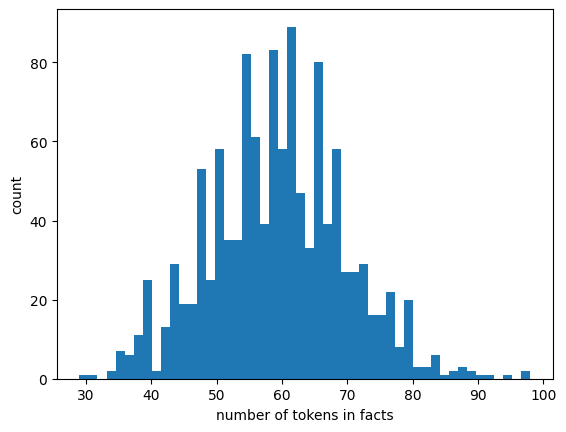

In [97]:
plt.hist(crime['facts_token_len'], bins=50)
plt.xlabel("number of tokens in facts")
plt.ylabel("count")
plt.show()

In [98]:
# finding short sentances that is less than 35 words
short_mask = crime['facts_token_len']<30

persentage_mask  = short_mask.mean() * 100

print(persentage_mask,"%")

0.08333333333333334 %


In [99]:
#Repeated boilerplate (duplicate texts):
duplicate_count = crime['facts'].value_counts()

duplicates = duplicate_count[duplicate_count>5]

print(duplicates.head())

Series([], Name: count, dtype: int64)


In [100]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    return [w for w in words if w not in stop_words and len(w) > 2]

all_words = []
for t in crime["facts"]:
    all_words.extend(tokenize(str(t)))

freq = Counter(all_words).most_common(20)
print(freq)


[('accused', 1342), ('bail', 882), ('case', 489), ('arrested', 417), ('court', 404), ('allegedly', 400), ('granted', 376), ('alleged', 320), ('fir', 297), ('petitioner', 295), ('custody', 294), ('act', 284), ('filed', 280), ('later', 259), ('ipc', 253), ('complainant', 235), ('section', 229), ('involving', 225), ('dowry', 193), ('sections', 189)]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ravichandran\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [101]:
import re
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    return [w for w in words if w not in stop_words and len(w) > 2]

all_words = []
for t in crime["facts"]:
    all_words.extend(tokenize(t))

freq = Counter(all_words).most_common(20)
print(freq)


[('accused', 1342), ('bail', 882), ('case', 489), ('arrested', 417), ('court', 404), ('allegedly', 400), ('granted', 376), ('alleged', 320), ('fir', 297), ('petitioner', 295), ('custody', 294), ('act', 284), ('filed', 280), ('later', 259), ('ipc', 253), ('complainant', 235), ('section', 229), ('involving', 225), ('dowry', 193), ('sections', 189)]


In [102]:
# counts
ct_counts = crime["crime_type"].value_counts()
print(ct_counts)

# percentages
ct_proportion = crime["crime_type"].value_counts(normalize=True) * 100
print(ct_proportion)


crime_type
Narcotics            134
Theft or Robbery     128
Dowry Harassment     123
Sexual Offense       121
Fraud or Cheating    121
Cyber Crime          116
Extortion            106
Kidnapping            95
Murder                89
Others                75
Domestic Violence     72
Attempt to Murder     20
Name: count, dtype: int64
crime_type
Narcotics            11.166667
Theft or Robbery     10.666667
Dowry Harassment     10.250000
Sexual Offense       10.083333
Fraud or Cheating    10.083333
Cyber Crime           9.666667
Extortion             8.833333
Kidnapping            7.916667
Murder                7.416667
Others                6.250000
Domestic Violence     6.000000
Attempt to Murder     1.666667
Name: proportion, dtype: float64


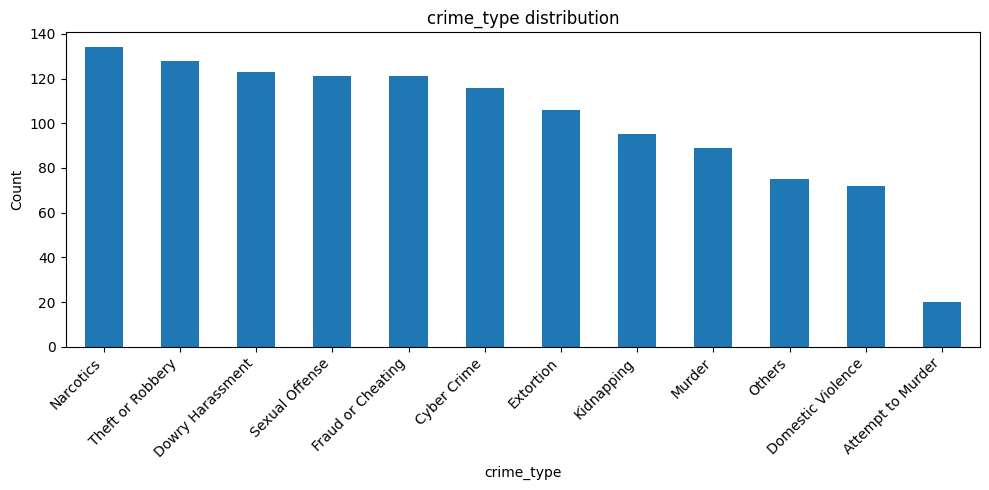

In [103]:

plt.figure(figsize=(10, 5))
ct_counts.plot(kind="bar")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("crime_type distribution")
plt.tight_layout()
plt.show()


In [104]:
# chevking ist any obivous
for ct in crime["crime_type"].unique():
    print("=== ", ct, " ===")
    print(crime[crime["crime_type"] == ct]["facts"].head(2).to_string(index=False))
    print()


===  Narcotics  ===
Jibangshu Paul was apprehended carrying Rs. 32,...
The petitioner was arrested with 6.71 grams of ...

===  Sexual Offense  ===
The case involves custodial rape of a woman by ...
Siddappa was arrested after marrying a 17-year-...

===  Fraud or Cheating  ===
Hyderali, a government contractor, was accused ...
The applicant was arrested in a case involving ...

===  Others  ===
The petitioner, a government employee, alleged ...
The appellant was accused in the 2006 Malegaon ...

===  Murder  ===
Shankri Devi and co-accused were charged with t...
Hardeep Singh @ Dipi, a juvenile, was implicate...

===  Dowry Harassment  ===
Laxmi, married to one of the appellants, died f...
Rahul Dutta, an Australian citizen, was accused...

===  Theft or Robbery  ===
The accused was arrested on 14.08.2020 for hous...
Ramjan Khan was accused in a motorcycle theft c...

===  Kidnapping  ===
The accused Pritam Kumar was alleged to have ki...
The accused Sanni Malik was implicated in a ki

In [105]:
crime['ipc_sections'].value_counts()

ipc_sections
[]                                                                                                                                                                                        205
['419', '420', '467', '468', '471', '120B']                                                                                                                                                45
['498A', '304B']                                                                                                                                                                           20
['392']                                                                                                                                                                                    20
['498A', '304B', '34']                                                                                                                                                                     14
                                     

In [106]:
print(crime['ipc_sections'].unique())

["['120B', '121', '121A']"
 "['376', '354', '343', '109', '220', '348', '330', '323']"
 "['465', '468', '471', '474', '420', '511', '34']"
 "['326', '307', '120B', '201']" "['302', '34']" "['302', '397', '201']"
 "['120B', '143', '341', '144', '148', '302', '201', '149']"
 "['302', '330']" "['147', '148', '302', '323', '149']" '[]' "['302']"
 "['302', '307', '143', '147', '148', '149', '341', '120B', '201', '449', '447']"
 "['302', '294', '323', '324', '307', '147', '148', '149', '506']"
 "['498A', '304B', '34']" "['498A', '406', '34', '174A']"
 "['143', '147', '148', '149', '341', '302']" "['304B', '498A']"
 "['304B', '306']" "['498A', '304B', '307', '326', '506']"
 "['498A', '304B']" "['376(1)', '376(2)(N)', '34']"
 "['363', '366', '376(ab)', '506']" "['363', '114', '366A', '376', '34']"
 "['363', '366', '366A', '368', '506(2)', '342', '354A', '376DA', '34']"
 "['365', '363', '366A', '370', '370A', '372', '373', '376', '120B', '34']"
 "['366', '376', '417']" "['376(2)(1)(n)']"
 "['36

In [107]:
crime['ipc_sections'][:10]

0                              ['120B', '121', '121A']
1    ['376', '354', '343', '109', '220', '348', '33...
2     ['465', '468', '471', '474', '420', '511', '34']
3                        ['326', '307', '120B', '201']
4                                        ['302', '34']
5                                ['302', '397', '201']
6    ['120B', '143', '341', '144', '148', '302', '2...
7                                       ['302', '330']
8                  ['147', '148', '302', '323', '149']
9                                                   []
Name: ipc_sections, dtype: object

In [108]:
import re

def parse_ipc_sections(text):
    if pd.isna(text):
        return []
    # keep digits + letters + commas
    text = str(text).upper()
    # replace common separators with comma
    text = re.sub(r"[;/|]+", ",", text)
    # split
    parts = [p.strip() for p in text.split(",") if p.strip()]
    # remove trailing 'IPC'
    cleaned = []
    for p in parts:
        p = p.replace("IPC", "").strip()
        if not p:
            continue
        cleaned.append(p)
    return cleaned

crime["ipc_list"] = crime["ipc_sections"].apply(parse_ipc_sections)


In [109]:
crime["ipc_count"] = crime["ipc_list"].str.len()

print(crime["ipc_count"].describe())
print("Rows with 0 IPC sections:", (crime["ipc_count"] == 0).mean() * 100, "%")


count    1200.000000
mean        4.025833
std         3.047607
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        25.000000
Name: ipc_count, dtype: float64
Rows with 0 IPC sections: 0.0 %


In [110]:
from collections import Counter

all_ipc = []
for lst in crime["ipc_list"]:
    all_ipc.extend(lst)

ipc_freq = Counter(all_ipc).most_common(30)
for sec, c in ipc_freq:
    print(sec, c)


'34'] 265
[] 205
'120B'] 170
'420' 164
'468' 152
'467' 142
'471' 130
'120B' 123
'506' 115
'323' 105
['498A' 104
['363' 87
'504' 81
'307' 75
['419' 74
['302' 67
['120B' 60
'302' 59
'148' 56
'506'] 53
'149' 47
'201' 46
'324' 44
['420' 44
'304B' 41
'406' 40
'34' 40
'147' 38
'341' 37
'498A' 35


In [111]:
# --- Homicide / attempt / dowry death / serious violence ---
IPC_TO_LABELS = {
    "302": ["homicide"],
    "304B": ["homicide", "domestic_violence"],
    "307": ["homicide"],
    "308": ["homicide"],
    "310": ["homicide"],
    "311": ["homicide"],
    "306": ["domestic_violence", "homicide"],
    "323": ["assault"],
    "324": ["assault", "weapon_used"],
    "325": ["grievous_hurt"],
    "326": ["grievous_hurt", "weapon_used"],
    "326A": ["grievous_hurt", "weapon_used"],
    "327": ["assault"],
    "329": ["grievous_hurt"],
    "330": ["assault"],
    "332": ["assault"],
    "333": ["grievous_hurt"],
    "336": ["assault"],
    "337": ["assault"],
    "338": ["grievous_hurt"],
    "341": ["assault"],
    "342": ["assault"],
    "343": ["assault"],
    "344": ["assault"],
    "346": ["assault"],
    "352": ["assault"],
    "355": ["assault"],
    "358": ["assault"],
    "498A": ["domestic_violence"],
    "494": ["domestic_violence"],
    "493": ["sexual_offence"],
    "354": ["sexual_offence"],
    "354A": ["sexual_offence"],
    "354B": ["sexual_offence"],
    "354C": ["sexual_offence"],
    "354D": ["sexual_offence"],
    "366A": ["sexual_offence"],
    "370": ["sexual_offence"],
    "370A": ["sexual_offence"],
    "372": ["sexual_offence"],
    "373": ["sexual_offence"],
    "376": ["sexual_offence"],
    "376(1)": ["sexual_offence"],
    "376(2)": ["sexual_offence"],
    "376(2)(F)": ["sexual_offence"],
    "376(2)(I)": ["sexual_offence"],
    "376(2)(I)(N)": ["sexual_offence"],
    "376(2)(K)": ["sexual_offence"],
    "376(2)(N)": ["sexual_offence"],
    "376(3)": ["sexual_offence"],
    "376AB": ["sexual_offence"],
    "376(AB)": ["sexual_offence"],
    "376(D)": ["sexual_offence"],
    "376D": ["sexual_offence"],
    "376DA": ["sexual_offence"],
    "377": ["sexual_offence"],
    "361": ["kidnapping"],
    "363": ["kidnapping"],
    "363A": ["kidnapping"],
    "364": ["kidnapping", "homicide"],
    "364A": ["kidnapping", "extortion"],
    "365": ["kidnapping"],
    "366": ["kidnapping"],
    "367": ["kidnapping"],
    "368": ["kidnapping"],
    "369": ["kidnapping"],
    "379": ["theft"],
    "379B": ["robbery", "assault"],
    "380": ["theft"],
    "381": ["theft"],
    "382": ["robbery"],
    "384": ["extortion"],
    "385": ["extortion"],
    "386": ["extortion"],
    "387": ["extortion"],
    "388": ["extortion"],
    "389": ["extortion"],
    "392": ["robbery"],
    "393": ["robbery"],
    "394": ["robbery", "assault"],
    "395": ["robbery"],
    "396": ["robbery", "homicide"],
    "397": ["robbery", "weapon_used"],
    "398": ["robbery", "weapon_used"],
    "399": ["robbery"],
    "401": ["robbery"],
    "402": ["robbery"],
    "406": ["fraud"],
    "407": ["fraud"],
    "408": ["fraud"],
    "409": ["fraud"],
    "411": ["fraud"],
    "412": ["fraud"],
    "413": ["fraud"],
    "414": ["fraud"],
    "415": ["cheating"],
    "417": ["cheating"],
    "418": ["cheating", "fraud"],
    "419": ["cheating", "fraud"],
    "420": ["cheating", "fraud"],
    "423": ["fraud"],
    "426": ["fraud"],
    "427": ["fraud"],
    "463": ["fraud"],
    "465": ["fraud"],
    "466": ["fraud"],
    "467": ["fraud"],
    "468": ["fraud"],
    "469": ["fraud"],
    "470": ["fraud"],
    "471": ["fraud"],
    "472": ["fraud"],
    "473": ["fraud"],
    "474": ["fraud"],
    "477": ["fraud"],
    "477A": ["fraud"],
    "489A": ["fraud"],
    "489B": ["fraud"],
    "489C": ["fraud"],
    "503": ["criminal_intimidation"],
    "504": ["criminal_intimidation"],
    "505(1)(B)": ["criminal_intimidation"],
    "506": ["criminal_intimidation"],
    "506(1)": ["criminal_intimidation"],
    "506(2)": ["criminal_intimidation"],
    "506(I)": ["criminal_intimidation"],
    "506(II)": ["criminal_intimidation"],
    "506B": ["criminal_intimidation"],
    "507": ["criminal_intimidation"],
    "509": ["criminal_intimidation"],
    "441": ["house_trespass"],
    "442": ["house_trespass"],
    "447": ["house_trespass"],
    "448": ["house_trespass"],
    "449": ["house_trespass"],
    "451": ["house_trespass"],
    "452": ["house_trespass"],
    "454": ["house_trespass"],
    "455": ["house_trespass"],
    "457": ["house_trespass"],
    "458": ["house_trespass", "weapon_used"],
    "459": ["house_trespass", "homicide"],
    "66E": ["cyber_crime"],
    "67": ["cyber_crime"],
    "67A": ["cyber_crime"],
    "25": ["weapon_used"],
    "25 ARMS ACT": ["weapon_used"],
    "25(1)(AA)": ["weapon_used"],
    "25(1-B)(A)": ["weapon_used"],
    "25(1-C) ARMS ACT": ["weapon_used"],
    "27": ["weapon_used"],
    "121": ["homicide"],
    "121A": ["homicide"],
    "122": ["homicide"],
    "124A": ["homicide"],
}

In [112]:

def normalize_ipc(sec: str) -> str:
    sec = str(sec).upper()
    sec = sec.replace("IPC", "").replace(".", "").strip()
    return sec

In [113]:
from collections import Counter

all_ipc_norm = []

for lst in crime["ipc_list"]:
    for sec in lst:
        sec_clean = normalize_ipc(sec)
        all_ipc_norm.append(sec_clean)

ipc_counter = Counter(all_ipc_norm)
print("Unique IPC sections:", len(ipc_counter))


Unique IPC sections: 491


In [114]:
for sec, c in sorted(ipc_counter.items(), key=lambda x: x[0]):
    print(sec, c)


'107' 1
'109' 25
'109'] 5
'109(1)' 1
'110' 1
'111' 1
'114' 6
'114'] 21
'115' 2
'116' 1
'119(2)' 1
'120B' 123
'120B'] 170
'121' 7
'121A' 8
'121A'] 3
'122' 2
'122'] 1
'123' 2
'124A' 1
'126(2)' 1
'13'] 1
'13(1)(D)' 2
'13(2)' 2
'141' 2
'142' 1
'143' 14
'143'] 2
'144' 6
'145' 1
'147' 38
'148' 56
'149' 47
'149'] 29
'150' 2
'153(A)'] 1
'153A' 4
'153A'] 4
'155' 3
'166' 1
'166A' 1
'167' 2
'168' 1
'170' 4
'171' 2
'174A'] 2
'175'] 1
'177' 1
'180'] 1
'182' 6
'186' 6
'186'] 1
'188' 7
'188'] 1
'189' 5
'193' 2
'195' 6
'195A' 1
'195A'] 1
'197' 1
'199' 1
'200' 1
'201' 46
'201'] 27
'202' 3
'203' 1
'203'] 1
'204' 2
'211' 1
'212' 10
'212'] 2
'213' 5
'214' 1
'216A' 1
'218' 1
'220' 1
'224' 2
'225' 1
'225B' 1
'25 ARMS ACT'] 2
'25' 3
'25(1)(AA)' 2
'25(1-C) ARMS ACT'] 1
'255' 1
'256' 1
'257' 1
'259' 1
'26' 1
'260' 1
'27' 4
'27'] 1
'270' 1
'29'] 2
'294' 13
'294(B)' 5
'294B' 7
'295' 5
'3' 1
'3(5) OF BNS 1
'3(5)'] 2
'302' 59
'302'] 4
'303' 2
'304B' 41
'304B'] 22
'306' 14
'306'] 3
'307' 75
'307'] 12
'308' 2
'310' 

In [115]:
import ast
import pandas as pd

def parse_ipc_sections(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
            return [val]
        except (SyntaxError, ValueError):
            return [x]
    return []

crime["ipc_list"] = crime["ipc_sections"].apply(parse_ipc_sections)

def labels_from_ipc_list(ipc_list):
    labels = set()
    for sec in ipc_list:
        sec_clean = normalize_ipc(sec)
        if sec_clean in IPC_TO_LABELS:
            labels.update(IPC_TO_LABELS[sec_clean])
    return list(labels)

crime["ipc_based_labels"] = crime["ipc_list"].apply(labels_from_ipc_list)

def combine_labels(row):
    labs = set(row["ipc_based_labels"])
    labs.add(row["crime_type"])
    return list(labs)

crime["final_labels"] = crime.apply(combine_labels, axis=1)
print(crime['final_labels'])


0                                   [Narcotics, homicide]
1               [Sexual Offense, sexual_offence, assault]
2                    [fraud, Fraud or Cheating, cheating]
3          [grievous_hurt, weapon_used, Others, homicide]
4                                      [Murder, homicide]
                              ...                        
1195                                             [Others]
1196                  [kidnapping, extortion, Kidnapping]
1197                 [fraud, Fraud or Cheating, cheating]
1198                                [weapon_used, Others]
1199    [fraud, Fraud or Cheating, cheating, criminal_...
Name: final_labels, Length: 1200, dtype: object


In [116]:
print(
    crime[["crime_type", "ipc_sections", "ipc_based_labels", "final_labels"]].head(10).to_string(index=False))


       crime_type                                              ipc_sections                       ipc_based_labels                                   final_labels
        Narcotics                                   ['120B', '121', '121A']                             [homicide]                          [Narcotics, homicide]
   Sexual Offense  ['376', '354', '343', '109', '220', '348', '330', '323']              [sexual_offence, assault]      [Sexual Offense, sexual_offence, assault]
Fraud or Cheating          ['465', '468', '471', '474', '420', '511', '34']                      [fraud, cheating]           [fraud, Fraud or Cheating, cheating]
           Others                             ['326', '307', '120B', '201'] [grievous_hurt, weapon_used, homicide] [grievous_hurt, weapon_used, Others, homicide]
           Murder                                             ['302', '34']                             [homicide]                             [Murder, homicide]
           Murder           

In [117]:
print("Rows with empty ipc_based_labels:",
      (crime["ipc_based_labels"].str.len() == 0).mean() * 100, "%")

print("Rows with empty final_labels:",
      (crime["final_labels"].str.len() == 0).mean() * 100, "%")


Rows with empty ipc_based_labels: 19.166666666666668 %
Rows with empty final_labels: 0.0 %


In [118]:
print(
    crime[["crime_type", "ipc_sections", "ipc_based_labels", "final_labels"]]
      .head(15)
      .to_string(index=False)
)


       crime_type                                                                   ipc_sections                                        ipc_based_labels                                                    final_labels
        Narcotics                                                        ['120B', '121', '121A']                                              [homicide]                                           [Narcotics, homicide]
   Sexual Offense                       ['376', '354', '343', '109', '220', '348', '330', '323']                               [sexual_offence, assault]                       [Sexual Offense, sexual_offence, assault]
Fraud or Cheating                               ['465', '468', '471', '474', '420', '511', '34']                                       [fraud, cheating]                            [fraud, Fraud or Cheating, cheating]
           Others                                                  ['326', '307', '120B', '201']                  [grievous_hurt, we

In [119]:
# not mapped lables 
unmapped_rows = crime[crime["ipc_based_labels"].str.len() == 0]
print(unmapped_rows[["facts", "ipc_sections"]].head(20).to_string(index=False))



                                                                                                                                                                                                                                                                                                                                                                                                                            facts          ipc_sections
                                                                                                                                        The petitioner was arrested with 6.71 grams of heroin along with two others during a police chase. The heroin was confirmed by a forensic report. The petitioner had prior NDPS cases, but no details were provided. Bail was sought under Section 439 CrPC after charge-sheet was filed.                    []
                                                  The applicant, arrested in 2016, was accused in three NDPS cases invol

In [120]:
crime.head()

,ipc_sections,crime_type,facts,legal_issues,judgment_reason,summary,region,special_laws,facts_lang,facts_token_len,ipc_list,ipc_count,ipc_based_labels,final_labels
0,"['120B', '121', '121A']",Narcotics,Jibangshu Paul was apprehended carrying Rs. 32...,"['Whether fresh bail is needed when new, more ...",The court held that newly added serious UA(P) ...,Bail earlier granted to Jibangshu Paul under I...,Assam,None,en,55,"[120B, 121, 121A]",3,[homicide],"[Narcotics, homicide]"
1,"['376', '354', '343', '109', '220', '348', '33...",Sexual Offense,The case involves custodial rape of a woman by...,['Whether suspension of sentence requires deta...,The court held that due to the grave nature of...,Madras High Court cancelled the bail granted t...,Tamil Nadu,None,en,52,"[376, 354, 343, 109, 220, 348, 330, 323]",8,"[sexual_offence, assault]","[Sexual Offense, sexual_offence, assault]"
2,"['465', '468', '471', '474', '420', '511', '34']",Fraud or Cheating,"Hyderali, a government contractor, was accused...",['Whether anticipatory bail can be granted whe...,The court ruled that despite other co-accused ...,Kerala High Court rejected anticipatory bail f...,Kerala,None,en,54,"[465, 468, 471, 474, 420, 511, 34]",7,"[fraud, cheating]","[fraud, Fraud or Cheating, cheating]"
3,"['326', '307', '120B', '201']",Others,"The petitioner, a government employee, alleged...",['Whether bail should be cancelled under Secti...,The court found no cogent or overwhelming reas...,Calcutta High Court refused to cancel bail of ...,West Bengal,None,en,49,"[326, 307, 120B, 201]",4,"[grievous_hurt, weapon_used, homicide]","[grievous_hurt, weapon_used, Others, homicide]"
4,"['302', '34']",Murder,Shankri Devi and co-accused were charged with ...,['Whether the court’s earlier bail rejection o...,The court held that its earlier rejection of b...,Jammu & Kashmir High Court rejected the review...,Jammu & Kashmir,None,en,49,"[302, 34]",2,[homicide],"[Murder, homicide]"


In [121]:
# token length of summary 
crime["summary_len"] = crime["summary"].fillna("").str.split().str.len()
print(crime["summary_len"].describe())

# % empty (0 tokens)
empty_summary_pct = (crime["summary_len"] == 0).mean() * 100
print("Empty summaries (%):", empty_summary_pct)


count    1200.000000
mean       25.392500
std         3.949866
min        13.000000
25%        23.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: summary_len, dtype: float64
Empty summaries (%): 0.0


In [122]:
# token length of judgment_reason
crime["reason_len"] = crime["judgment_reason"].fillna("").str.split().str.len()
print(crime["reason_len"].describe())

empty_reason_pct = (crime["reason_len"] == 0).mean() * 100
print("Empty judgment_reason (%):", empty_reason_pct)


count    1200.000000
mean       38.826667
std         9.633654
min        16.000000
25%        32.000000
50%        39.000000
75%        45.000000
max        74.000000
Name: reason_len, dtype: float64
Empty judgment_reason (%): 0.0


In [123]:
# empties for leagel issues 
crime["legal_issues_len"] = crime["legal_issues"].fillna("").str.strip().str.len()
empty_li_pct = (crime["legal_issues_len"] == 0).mean() * 100
print("Empty legal_issues (%):", empty_li_pct)

# small sample
print(crime["legal_issues"].head(10).to_string(index=False))


Empty legal_issues (%): 0.0
['Whether fresh bail is needed when new, more s...
['Whether suspension of sentence requires detai...
['Whether anticipatory bail can be granted when...
['Whether bail should be cancelled under Sectio...
['Whether the court’s earlier bail rejection or...
['Whether Section 12 of the Juvenile Justice Ac...
['Whether the petitioner, being the main conspi...
['Whether anticipatory bail can be granted in a...
['Whether default bail under Section 167(2) CrP...
['Whether judicial custody serves any purpose i...


In [124]:
# finding unique regions 
print("Unique regions:", crime["region"].nunique())
print(crime["region"].value_counts())

# cross-tab with crime_type
print(pd.crosstab(crime["region"], crime["crime_type"]))


Unique regions: 28
region
Uttar Pradesh         130
Bihar                 121
Karnataka             120
Delhi                 119
Maharashtra           115
Punjab                100
Madhya Pradesh         99
Jharkhand              70
Gujarat                54
Himachal Pradesh       36
Rajasthan              34
Kerala                 32
Haryana                32
Chhattisgarh           22
West Bengal            18
Tamil Nadu             18
Assam                  15
Telangana              14
Odisha                 13
Jammu & Kashmir         9
Tripura                 9
Andhra Pradesh          7
Manipur                 4
Uttarakhand             3
Ladakh                  2
Chandigarh              2
Puducherry              1
Punjab and Haryana      1
Name: count, dtype: int64


crime_type          Attempt to Murder  Cyber Crime  Domestic Violence  \
region                                                                  
Andhra Pradesh                      0            0                  0   
Assam                               0            1                  2   
Bihar                               0           16                 10   
Chandigarh                          0            1                  0   
Chhattisgarh                        0            0                  0   
Delhi                               0            2                  3   
Gujarat                             1            1                  2   
Haryana                             0            3                  1   
Himachal Pradesh                    1            0                  2   
Jammu & Kashmir                     0            0                  0   
Jharkhand                           1           30                  3   
Karnataka                           1            3 

In [125]:
# special laws 
special_empty_pct = crime["special_laws"].isna().mean() * 100
print("Empty special_laws (%):", special_empty_pct)

print(crime["special_laws"].dropna().head(10).to_string(index=False))


Empty special_laws (%): 96.91666666666666
['MCOCA Section 3 & 4', 'Arms Act Sections 25 &...
['MCOCA Section 3(1)(i)', '3(2)', '3(4)', 'Arms...
['NDPS Act Sections 21', '29', 'Arms Act Sectio...
['Prevention of Corruption Act Section 13(2) re...
                                                []
              ['25(1-b)(a)', '35 of the Arms Act']
                    ['25', '54', '59 of Arms Act']
              ['25(1-b)(a)', '35 of the Arms Act']
              ['25(1-b)(a)', '35 of the Arms Act']
              ['25(1-b)(a)', '35 of the Arms Act']


In [126]:
crime.drop(['special_laws'] , axis= 1 , inplace=True)
crime.head()

,ipc_sections,crime_type,facts,legal_issues,judgment_reason,summary,region,facts_lang,facts_token_len,ipc_list,ipc_count,ipc_based_labels,final_labels,summary_len,reason_len,legal_issues_len
0,"['120B', '121', '121A']",Narcotics,Jibangshu Paul was apprehended carrying Rs. 32...,"['Whether fresh bail is needed when new, more ...",The court held that newly added serious UA(P) ...,Bail earlier granted to Jibangshu Paul under I...,Assam,en,55,"[120B, 121, 121A]",3,[homicide],"[Narcotics, homicide]",28,36,239
1,"['376', '354', '343', '109', '220', '348', '33...",Sexual Offense,The case involves custodial rape of a woman by...,['Whether suspension of sentence requires deta...,The court held that due to the grave nature of...,Madras High Court cancelled the bail granted t...,Tamil Nadu,en,52,"[376, 354, 343, 109, 220, 348, 330, 323]",8,"[sexual_offence, assault]","[Sexual Offense, sexual_offence, assault]",29,53,244
2,"['465', '468', '471', '474', '420', '511', '34']",Fraud or Cheating,"Hyderali, a government contractor, was accused...",['Whether anticipatory bail can be granted whe...,The court ruled that despite other co-accused ...,Kerala High Court rejected anticipatory bail f...,Kerala,en,54,"[465, 468, 471, 474, 420, 511, 34]",7,"[fraud, cheating]","[fraud, Fraud or Cheating, cheating]",29,56,285
3,"['326', '307', '120B', '201']",Others,"The petitioner, a government employee, alleged...",['Whether bail should be cancelled under Secti...,The court found no cogent or overwhelming reas...,Calcutta High Court refused to cancel bail of ...,West Bengal,en,49,"[326, 307, 120B, 201]",4,"[grievous_hurt, weapon_used, homicide]","[grievous_hurt, weapon_used, Others, homicide]",27,40,304
4,"['302', '34']",Murder,Shankri Devi and co-accused were charged with ...,['Whether the court’s earlier bail rejection o...,The court held that its earlier rejection of b...,Jammu & Kashmir High Court rejected the review...,Jammu & Kashmir,en,49,"[302, 34]",2,[homicide],"[Murder, homicide]",29,42,256


In [130]:
# the final labels looks all are mixed so its need to be normalise to one structure 
CORE_LABELS = {
    "theft",
    "robbery",
    "assault",
    "grievous_hurt",
    "weapon_used",
    "criminal_intimidation",
    "house_trespass",
    "cheating",
    "fraud",
    "cyber_crime",
    "sexual_offence",
    "domestic_violence",
    "kidnapping",
    "extortion",
    "homicide",
}

In [131]:
DATASET_LABEL_MAP = {
    "Murder": ["homicide"],
    "Sexual Offense": ["sexual_offence"],
    "Fraud or Cheating": ["fraud", "cheating"],
    "Theft or Robbery": ["theft", "robbery"],
    "Domestic Violence": ["domestic_violence"],
    "Attempt to Murder": ["homicide"],
    "Cyber Crime": ["cyber_crime"],
    "Kidnapping": ["kidnapping"],
    "Extortion": ["extortion"],
    "Dowry Harassment": ["domestic_violence"],
    "Others": []   # it should not add other or invent new labels 
}

In [132]:
def normalize_final_labels(row):
    labels = set(row["ipc_based_labels"])

    dataset_labels = DATASET_LABEL_MAP.get(row["crime_type"], [])
    for l in dataset_labels:
        labels.add(l)

    return list(labels)

In [133]:
crime["final_labels"] = crime.apply(normalize_final_labels, axis=1)

In [135]:
crime.head()

,ipc_sections,crime_type,facts,legal_issues,judgment_reason,summary,region,facts_lang,facts_token_len,ipc_list,ipc_count,ipc_based_labels,final_labels,summary_len,reason_len,legal_issues_len
0,"['120B', '121', '121A']",Narcotics,Jibangshu Paul was apprehended carrying Rs. 32...,"['Whether fresh bail is needed when new, more ...",The court held that newly added serious UA(P) ...,Bail earlier granted to Jibangshu Paul under I...,Assam,en,55,"[120B, 121, 121A]",3,[homicide],[homicide],28,36,239
1,"['376', '354', '343', '109', '220', '348', '33...",Sexual Offense,The case involves custodial rape of a woman by...,['Whether suspension of sentence requires deta...,The court held that due to the grave nature of...,Madras High Court cancelled the bail granted t...,Tamil Nadu,en,52,"[376, 354, 343, 109, 220, 348, 330, 323]",8,"[sexual_offence, assault]","[sexual_offence, assault]",29,53,244
2,"['465', '468', '471', '474', '420', '511', '34']",Fraud or Cheating,"Hyderali, a government contractor, was accused...",['Whether anticipatory bail can be granted whe...,The court ruled that despite other co-accused ...,Kerala High Court rejected anticipatory bail f...,Kerala,en,54,"[465, 468, 471, 474, 420, 511, 34]",7,"[fraud, cheating]","[fraud, cheating]",29,56,285
3,"['326', '307', '120B', '201']",Others,"The petitioner, a government employee, alleged...",['Whether bail should be cancelled under Secti...,The court found no cogent or overwhelming reas...,Calcutta High Court refused to cancel bail of ...,West Bengal,en,49,"[326, 307, 120B, 201]",4,"[grievous_hurt, weapon_used, homicide]","[grievous_hurt, weapon_used, homicide]",27,40,304
4,"['302', '34']",Murder,Shankri Devi and co-accused were charged with ...,['Whether the court’s earlier bail rejection o...,The court held that its earlier rejection of b...,Jammu & Kashmir High Court rejected the review...,Jammu & Kashmir,en,49,"[302, 34]",2,[homicide],[homicide],29,42,256


In [136]:
crime.columns

Index(['ipc_sections', 'crime_type', 'facts', 'legal_issues',
       'judgment_reason', 'summary', 'region', 'facts_lang', 'facts_token_len',
       'ipc_list', 'ipc_count', 'ipc_based_labels', 'final_labels',
       'summary_len', 'reason_len', 'legal_issues_len'],
      dtype='object')

In [137]:
crime.shape

(1200, 16)

In [139]:
# checking final labels empty labels 
crime[crime['final_labels'].apply(len)==0]

,ipc_sections,crime_type,facts,legal_issues,judgment_reason,summary,region,facts_lang,facts_token_len,ipc_list,ipc_count,ipc_based_labels,final_labels,summary_len,reason_len,legal_issues_len
9,[],Narcotics,The petitioner was arrested with 6.71 grams of...,['Whether judicial custody serves any purpose ...,The court noted that the quantity was intermed...,Himachal Pradesh High Court granted bail to an...,Himachal Pradesh,en,47,[],1,[],[],26,42,227
13,[],Narcotics,"The applicant, arrested in 2016, was accused i...",['Whether statements under Section 67 NDPS Act...,The court held that in light of the Supreme Co...,Bombay High Court granted bail to a 70-year-ol...,Maharashtra,en,62,[],1,[],[],27,50,277
49,[],Narcotics,Rhea Chakraborty was arrested under multiple N...,Whether Section 27A NDPS applies to accused wh...,The Court held that there was no material sugg...,Bombay High Court granted bail to Rhea Chakrab...,Maharashtra,en,61,[],1,[],[],24,44,146
50,[],Narcotics,Navinkumar Pandu Jatot and others were arreste...,Whether a charge sheet under NDPS Act filed wi...,The Court held that the charge sheet filed wit...,Bombay High Court granted default bail in NDPS...,Maharashtra,en,48,[],1,[],[],24,53,186
64,[],Narcotics,"On 11.07.2021, police based on information rai...",Whether anticipatory bail granted in an NDPS c...,The High Court found that the Special Judge ex...,High Court refused to cancel anticipatory bail...,Tripura,en,45,[],1,[],[],23,34,183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,[],Narcotics,Yash Gupta was implicated in a narcotics case ...,Whether the accused had conscious possession o...,"The court emphasized Article 21 rights, noting...",Bail granted to Yash Gupta due to prolonged pr...,Delhi,en,66,[],1,[],[],20,48,182
1082,[],Narcotics,Ranilal Gallaji Purohit was convicted under th...,Whether the High Court retains the power under...,The Court held that the judicial power under S...,The Gujarat High Court reaffirmed that appella...,Gujarat,en,67,[],1,[],[],30,53,163
1083,[],Narcotics,Powell Nwawa Ogechi was arrested under the NDP...,Whether an accused is entitled to default bail...,The Court held that the right to default bail ...,Delhi High Court ruled that accused are entitl...,Delhi,en,71,[],1,[],[],42,66,226
1084,[],Others,"The petitioner, Pradeep Kumar Singh, faced pro...",Whether interim bail can be granted pending de...,"The Court, relying on precedents, observed tha...",Allahabad High Court ruled that interim bail c...,Uttar Pradesh,en,84,[],1,[],[],32,40,189


In [140]:
crime.isnull().sum()

ipc_sections        0
crime_type          0
facts               0
legal_issues        0
judgment_reason     0
summary             0
region              0
facts_lang          0
facts_token_len     0
ipc_list            0
ipc_count           0
ipc_based_labels    0
final_labels        0
summary_len         0
reason_len          0
legal_issues_len    0
dtype: int64

In [141]:
crime.to_csv('dataset_A_clean.csv' , index=False)